#### Import

In [1]:
import pathlib
from pathlib import Path

#import cartopy.crs as ccrs
#import filefisher

import importlib
import matplotlib.pyplot as plt
import calendar
import numpy as np
import xarray as xr
import pandas as pd
from xarray import DataTree
import math


import warnings
import Play
import mesmer
import model 
import sklearn

import xskillscore as xs

from scipy.stats import (
    norm,
    gamma,
    beta,
    expon,
    weibull_min,
    lognorm,
    uniform,
    t,
    pareto
)

#from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression


In [2]:
tas = Play.shape_data.show_data_set("tas")
pr = Play.shape_data.show_data_set("pr")
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.mean("lat").mean("lon")
pr = pr.mean("lat").mean("lon")
mes_predictors = xr.merge([tas,pr]).drop_vars("file_qf")

In [3]:
target = Play.shape_data.show_data_set("mrsol").isel(depth = 0)

target = Play.shape_data.prune_group_ds_timespan(target, Month_idx=1)

target = target.drop_vars("depth_bnds")


mes_target = target.mean("lat").mean("lon")


In [4]:
tuple(mes_predictors.values())
mes_predictors_concat = xr.concat(
            tuple(mes_predictors.values()),
            dim="predictor",
            join="exact",
            coords="minimal",
        )
mes_predictors_concat = mes_predictors_concat.assign_coords(
            {"predictor": list(mes_predictors.keys())}
        )

In [5]:
mes_predictors_concat

<xarray.DataArray 'tas' (predictor: 2, time: 50)> Size: 800B
array([[2.75559822e+02, 2.75098800e+02, 2.75987479e+02, 2.75852070e+02,
        2.76379805e+02, 2.75612710e+02, 2.75373530e+02, 2.75301837e+02,
        2.75919089e+02, 2.75834489e+02, 2.75924519e+02, 2.76003144e+02,
        2.75908992e+02, 2.75794177e+02, 2.76116366e+02, 2.76055504e+02,
        2.75694799e+02, 2.76175613e+02, 2.75975679e+02, 2.75770840e+02,
        2.75629988e+02, 2.75906419e+02, 2.75981290e+02, 2.75866778e+02,
        2.76217896e+02, 2.75476368e+02, 2.75209707e+02, 2.75482444e+02,
        2.75748093e+02, 2.76159796e+02, 2.75496579e+02, 2.75378011e+02,
        2.75585619e+02, 2.75565400e+02, 2.75828733e+02, 2.75390638e+02,
        2.75693155e+02, 2.75478344e+02, 2.75722232e+02, 2.76067104e+02,
        2.75783628e+02, 2.75212278e+02, 2.75650521e+02, 2.75223495e+02,
        2.75449658e+02, 2.75802261e+02, 2.75711662e+02, 2.75841684e+02,
        2.75573749e+02, 2.75532860e+02],
       [2.61633031e-05, 2.59467863e-05, 2.62518105e-05, 2.64117456e-05,
        2.60959250e-05, 2.64735073e-05, 2.60788016e-05, 2.57398269e-05,
        2.56681819e-05, 2.68642713e-05, 2.64967004e-05, 2.63859500e-05,
        2.58146949e-05, 2.62270850e-05, 2.62550925e-05, 2.59741348e-05,
        2.60750833e-05, 2.60931356e-05, 2.62614701e-05, 2.57694984e-05,
        2.61287908e-05, 2.58674416e-05, 2.61164339e-05, 2.61767540e-05,
        2.65336494e-05, 2.58767434e-05, 2.60526507e-05, 2.56466237e-05,
        2.56136851e-05, 2.60785141e-05, 2.59252704e-05, 2.58575519e-05,
        2.56638574e-05, 2.56513743e-05, 2.58213381e-05, 2.52863749e-05,
        2.57595233e-05, 2.59821602e-05, 2.54714036e-05, 2.62555884e-05,
        2.57195625e-05, 2.59811247e-05, 2.53572945e-05, 2.58269010e-05,
        2.57955851e-05, 2.63646238e-05, 2.61726304e-05, 2.62298122e-05,
        2.60647074e-05, 2.62896718e-05]])
Coordinates:
  * predictor  (predictor) <U3 24B 'tas' 'pr'
  * time       (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
    height     float64 8B 2.0
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [6]:
mesmer_LinReg = mesmer.stats.LinearRegression()
mesmer_LinReg.fit(predictors=mes_predictors,target=mes_target.mrsol,dim="time")

In [7]:
tas = Play.shape_data.show_data_set("tas")
pr = Play.shape_data.show_data_set("pr")
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.isel(
    lat=slice(25, 35),
    lon=slice(4, 14)
)

tas = tas.stack(gridcell=("lat","lon"))

pr = pr.isel(
    lat=slice(25, 35),
    lon=slice(4, 14)
)

pr = pr.stack(gridcell=("lat","lon"))
predictors = xr.merge([tas,pr]).drop_vars("file_qf")

In [ ]:
#predictorsmin_lat_idx=25,max_lat_idx=35, lon_idx=4, max_lon_idx=14

SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3370828653.py, line 1)

In [9]:
target = Play.shape_data.show_data_set("mrsol")#.isel(depth = 0)

target = Play.shape_data.prune_group_ds_timespan(target, Month_idx=1)

target = target.drop_vars("depth_bnds")


target = target.isel(
    lat=slice(25, 35),
    lon=slice(4, 14)
)

target = target.stack(gridcell=("lat","lon"))


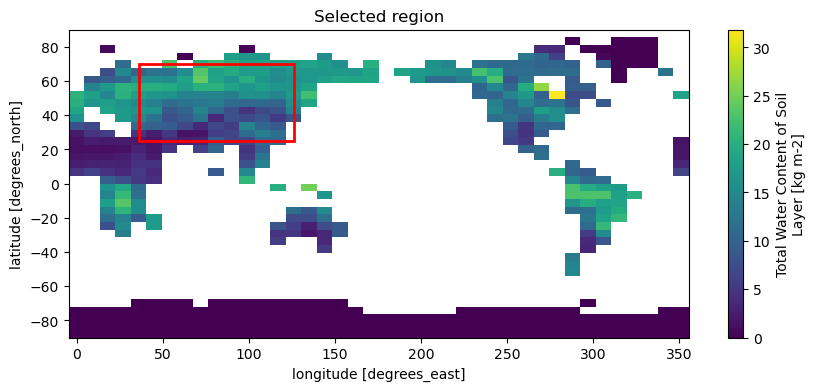

In [10]:
Play.plot_one_var.show_my_position(min_lat_idx=25,max_lat_idx=35, lon_idx=4, max_lon_idx=14)

In [11]:
target

<xarray.Dataset> Size: 203kB
Dimensions:   (time: 50, depth: 5, gridcell: 100)
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * depth     (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
  * gridcell  (gridcell) object 800B MultiIndex
  * lat       (gridcell) float64 800B 24.75 24.75 24.75 ... 65.25 65.25 65.25
  * lon       (gridcell) float64 800B 36.0 45.0 54.0 63.0 ... 99.0 108.0 117.0
Data variables:
    mrsol     (time, depth, gridcell) float64 200kB 2.126 1.687 ... 0.0 0.0
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:02 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/0fd5d006-722a-4650-a835-398b6aae92c9
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Emon/mrsol/MP...
    original_file_hash_codes:  35dde960416cda436bd90358a67f602de138e51219997c...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [12]:
tuple(predictors.values())

(<xarray.DataArray 'tas' (time: 50, gridcell: 100)> Size: 40kB
 array([[290.352775  , 284.45091079, 290.75714348, ..., 235.40044364,
         235.50835171, 236.1423086 ],
        [290.14036659, 285.85713873, 291.48666396, ..., 243.04779013,
         242.98255692, 243.58358576],
        [291.8522557 , 285.60012391, 289.7103655 , ..., 234.60469962,
         234.71148563, 237.25149534],
        ...,
        [292.16699148, 283.80608872, 289.84097726, ..., 240.87764769,
         239.602505  , 239.01997903],
        [289.17448193, 281.95939488, 288.83181436, ..., 238.59654317,
         237.58374531, 236.3638194 ],
        [290.0051784 , 286.50462204, 291.71212787, ..., 249.26014481,
         247.26062157, 242.95856286]], shape=(50, 100))
 Coordinates:
   * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
   * gridcell  (gridcell) object 800B MultiIndex
   * lat       (gridcell) float64 800B 24.75 24.75 24.75 ... 65.25 65.25 65.25
   * lon       (gridcell) float64 800

In [13]:
predictors_concat = xr.concat(
            tuple(predictors.values()),
            dim="predictor",
            join="exact",
            coords="minimal",
        )
predictors_concat = predictors_concat.assign_coords(
            {"predictor": list(predictors.keys())}
        )

predictors_concat = predictors_concat.transpose("gridcell","time","predictor")
predictors_concat.dims

('gridcell', 'time', 'predictor')

In [14]:
location_dim = "gridcell"
location = 0
predictors_concat.isel({location_dim: location})


<xarray.DataArray 'tas' (time: 50, predictor: 2)> Size: 800B
array([[2.90352775e+02, 1.35891605e-07],
       [2.90140367e+02, 9.73464199e-08],
       [2.91852256e+02, 4.53222933e-07],
       [2.90212674e+02, 1.00041960e-08],
       [2.93481089e+02, 5.83296489e-08],
       [2.92519881e+02, 2.54792811e-09],
       [2.91964937e+02, 1.96486865e-07],
       [2.90467248e+02, 1.41341227e-06],
       [2.92535527e+02, 4.74672563e-07],
       [2.91088925e+02, 3.08423208e-08],
       [2.89894025e+02, 4.72058988e-08],
       [2.90934866e+02, 3.67609579e-07],
       [2.89540175e+02, 2.02934926e-06],
       [2.92462854e+02, 1.43380197e-07],
       [2.91692908e+02, 1.25611992e-07],
       [2.92038577e+02, 3.70900621e-08],
       [2.89284745e+02, 3.62705145e-07],
       [2.91958163e+02, 1.15316195e-07],
       [2.92962195e+02, 7.13900285e-07],
       [2.89828156e+02, 1.03963612e-06],
...
       [2.88211124e+02, 1.35052304e-07],
       [2.91929287e+02, 1.18940064e-08],
       [2.92334650e+02, 1.79899063e-07],
       [2.92889335e+02, 1.42206930e-07],
       [2.92097891e+02, 7.94928331e-07],
       [2.88855028e+02, 1.29173735e-06],
       [2.90654592e+02, 2.94995059e-07],
       [2.90540966e+02, 4.45400273e-07],
       [2.91395400e+02, 3.04387108e-08],
       [2.91673411e+02, 1.31812675e-07],
       [2.92059699e+02, 4.48986153e-07],
       [2.90477819e+02, 2.30073817e-07],
       [2.90452956e+02, 5.00807738e-07],
       [2.93216377e+02, 6.18815427e-09],
       [2.91532201e+02, 4.11179790e-09],
       [2.90057582e+02, 1.62735395e-07],
       [2.94436922e+02, 1.29896251e-06],
       [2.92166991e+02, 1.43840801e-06],
       [2.89174482e+02, 4.80794274e-07],
       [2.90005178e+02, 3.21728282e-07]])
Coordinates:
  * time       (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * predictor  (predictor) <U3 24B 'tas' 'pr'
    height     float64 8B 2.0
    gridcell   object 8B (np.float64(24.75), np.float64(36.0))
    lat        float64 8B 24.75
    lon        float64 8B 36.0
Attributes:
    standard_name:  air_temperature
    long_name:      Near-Surface Air Temperature
    units:          K
    comment:        near-surface (usually, 2 meter) air temperature
    cell_methods:   area: time: mean
    cell_measures:  area: areacella

In [15]:
importlib.reload(model.stats._parallel_linear_regression)
from model.stats._parallel_linear_regression import ParLinearRegression

model_par_LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
model_par_LinReg.fit(predictors=predictors,target=target.mrsol,location_dim="gridcell",regr_dim="time",parallel = True)

In [16]:
importlib.reload(model.stats._parallel_linear_regression)
from model.stats._parallel_linear_regression import ParLinearRegression

model_ser_LinReg = model.stats._parallel_linear_regression.ParLinearRegression()
model_ser_LinReg.fit(predictors=predictors,target=target.mrsol,location_dim="gridcell",regr_dim="time",parallel = False)

In [38]:
model_par_LinReg.params

<xarray.Dataset> Size: 14kB
Dimensions:        (gridcell: 100, depth: 5)
Coordinates:
  * gridcell       (gridcell) object 800B MultiIndex
  * lat            (gridcell) float64 800B 24.75 24.75 24.75 ... 65.25 65.25
  * lon            (gridcell) float64 800B 36.0 45.0 54.0 ... 99.0 108.0 117.0
  * depth          (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
Data variables:
    intercept      (gridcell, depth) float64 4kB -8.331 15.1 52.65 ... 0.0 0.0
    tas            (gridcell, depth) float64 4kB 0.03507 0.0298 ... 0.0 0.0
    pr             (gridcell, depth) float64 4kB 4.01e+05 1.656e+05 ... 0.0 0.0
    fit_intercept  bool 1B True

In [ ]:
model_vec_LinReg.predict(predictors=predictors_2)

<xarray.Dataset> Size: 13kB
Dimensions:     (time: 50, gridcell: 6, depth: 5)
Coordinates:
  * time        (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell    (gridcell) object 48B MultiIndex
  * lat         (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon         (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
  * depth       (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height      float64 8B 2.0
Data variables:
    prediction  (depth, gridcell, time) float64 12kB 7.704 8.526 ... 0.6339

In [ ]:
model_vec_LinReg.residuals(predictors=predictors_2,target=mrsol)

<xarray.DataArray 'residuals' (time: 50, gridcell: 6, depth: 5)> Size: 12kB
array([[[-3.14474273e-01, -3.51261449e+01, -6.94111714e+01,
          7.16108771e+00,  7.38925838e+00],
        [-9.29708677e-02, -3.61779895e+01, -4.60196557e+01,
          6.53566804e+00,  6.52769607e+00],
        [ 5.72230285e-01, -3.36879859e+01, -8.24392776e+01,
         -6.71621463e+00,  1.02085935e+01],
        [ 7.67250070e-01, -3.66081191e+01, -9.13211291e+01,
         -2.22099659e+01,  1.25684146e+01],
        [-6.08924865e-01, -3.51339342e+01, -5.85453670e+01,
          1.17012267e+01,  1.17012243e+01],
        [ 8.85882689e-01, -3.08147848e+01, -6.77844433e+01,
         -8.38081408e+00,  1.00842353e+01]],

       [[-3.29563007e+00, -3.77182888e+01, -7.17291259e+01,
          5.05679230e+00,  5.23063149e+00],
        [ 1.31548063e+00, -3.29523828e+01, -4.35040811e+01,
          9.76813395e+00,  9.75680495e+00],
        [ 2.30457068e+00, -3.20856374e+01, -8.61982725e+01,
         -1.04972662e+00,  1.15504554e+01],
        [-4.48072434e-01, -3.53531170e+01, -8.66649218e+01,
...
         -9.32609674e+00,  1.12274382e+01],
        [-2.08867112e+00, -3.89904640e+01, -1.00673009e+02,
         -2.56906192e+01,  1.02745284e+01],
        [-1.34384242e+00, -3.59510318e+01, -5.95684587e+01,
          1.06627916e+01,  1.06627789e+01],
        [-7.15402150e-01, -3.30804889e+01, -7.12071006e+01,
         -9.69868104e+00,  9.69973808e+00]],

       [[ 4.22002105e-01, -3.33455351e+01, -6.87794220e+01,
          6.86568686e+00,  7.08979334e+00],
        [ 2.94938678e+00, -3.27859328e+01, -4.24960830e+01,
          9.58056570e+00,  9.57166600e+00],
        [-3.92635525e-01, -3.36506834e+01, -8.24736087e+01,
         -6.55076415e+00,  6.68181628e+00],
        [-1.29166534e+00, -3.81997425e+01, -8.45890130e+01,
         -2.30164458e+01,  9.79629736e+00],
        [ 3.47061575e+00, -2.99575387e+01, -5.62422341e+01,
          1.12042348e+01,  1.12042017e+01],
        [-7.11040217e-01, -3.09656627e+01, -6.80924397e+01,
         -9.50994985e+00,  6.44299721e+00]]], shape=(50, 6, 5))
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell  (gridcell) object 48B MultiIndex
  * lat       (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon       (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
  * depth     (depth) float64 40B 0.03 0.19 0.78 2.68 6.98
    height    float64 8B 2.0
Attributes:
    standard_name:  mass_content_of_water_in_soil_layer
    long_name:      Total Water Content of Soil Layer
    units:          kg m-2
    comment:        in each soil layer, the mass of water in all phases, incl...
    cell_measures:  area: areacella
    history:        2019-09-02T13:09:20Z altered by CMOR: Reordered dimension...

In [158]:
regr_mat = Play.LinReg_building.global_vars_to_one_dim(min_lat_idx=27, max_lat_idx= 29, min_lon_idx=5, max_lon_idx=8, Month_idx=1, end="1900-01-01")

In [164]:
regr_mat[1][2].intercept_

np.float64(50.91856695816045)

In [97]:
print(regr.coef_)
regr.intercept_

[-2.07036945e-01  1.81877603e+05]


np.float64(64.55990341763358)

In [11]:
model_linReg = model.stats.LinearRegression()

In [12]:
model_linReg.fit(predictors=predictors,target=target.mrsol,dim="time")

In [13]:
mesmer_LinReg.params

<xarray.Dataset> Size: 289B
Dimensions:        (gridcell: 6)
Coordinates:
  * gridcell       (gridcell) object 48B MultiIndex
  * lat            (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon            (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
Data variables:
    intercept      (gridcell) float64 48B -418.9 -237.0 -359.2 ... -454.0 -213.9
    tas            (gridcell) float64 48B 1.605 0.9231 1.471 0.1699 1.62 0.821
    pr             (gridcell) float64 48B -5.853e+05 -3.889e+05 ... -1.114e+05
    fit_intercept  bool 1B True

In [14]:
mesmer_LinReg.params

<xarray.Dataset> Size: 289B
Dimensions:        (gridcell: 6)
Coordinates:
  * gridcell       (gridcell) object 48B MultiIndex
  * lat            (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon            (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
Data variables:
    intercept      (gridcell) float64 48B -418.9 -237.0 -359.2 ... -454.0 -213.9
    tas            (gridcell) float64 48B 1.605 0.9231 1.471 0.1699 1.62 0.821
    pr             (gridcell) float64 48B -5.853e+05 -3.889e+05 ... -1.114e+05
    fit_intercept  bool 1B True

In [16]:
tas = Play.shape_data.show_data_set("tas", run_idx=2)
pr = Play.shape_data.show_data_set("pr", run_idx=2)
tas = Play.shape_data.prune_group_ds_timespan(tas, Month_idx=1)
pr = Play.shape_data.prune_group_ds_timespan(pr, Month_idx=1)
tas = tas.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

tas = tas.stack(gridcell=("lat","lon"))

pr = pr.isel(
    lat=slice(27, 29),
    lon=slice(5, 8)
)

pr = pr.stack(gridcell=("lat","lon"))
predictors_2 = xr.merge([tas,pr]).drop_vars("file_qf")

In [166]:
predictors_2

<xarray.Dataset> Size: 5kB
Dimensions:   (time: 50, gridcell: 6)
Coordinates:
  * time      (time) datetime64[ns] 400B 1850-01-31 1851-01-31 ... 1899-01-31
  * gridcell  (gridcell) object 48B MultiIndex
  * lat       (gridcell) float64 48B 33.75 33.75 33.75 38.25 38.25 38.25
  * lon       (gridcell) float64 48B 45.0 54.0 63.0 45.0 54.0 63.0
    height    float64 8B 2.0
Data variables:
    tas       (time, gridcell) float64 2kB 280.7 277.5 275.1 ... 277.4 274.1
    pr        (time, gridcell) float64 2kB 6.902e-06 4.118e-06 ... 1.127e-06
Attributes: (12/52)
    CDI:                       Climate Data Interface version 1.9.6 (http://m...
    history:                   Wed Jul 15 10:14:10 2026: cdo remapbil,r40x40 ...
    source:                    MPI-ESM1.2-LR (2017): \naerosol: none, prescri...
    institution:               Max Planck Institute for Meteorology
    Conventions:               CF-1.7 CMIP-6.2
    activity_id:               CMIP
    ...                        ...
    cmor_version:              3.5.0
    tracking_id:               hdl:21.14100/1e556aad-382b-474a-b282-59c8bf9b6421
    cmip6-ng:                  \ncontact = cmip6-archive@env.ethz.ch\ndescrip...
    original_file_names:       /net/atmos/data/cmip6/historical/Amon/tas/MPI-...
    original_file_hash_codes:  ccbabc2709d37dde96079a7fd7e7e91fb74d6d4785fbbe...
    CDO:                       Climate Data Operators version 1.9.6 (http://m...

In [172]:
pred = model_vec_LinReg.predict(predictors_2)

In [17]:
mrsol = Play.shape_data.show_data_set("mrsol", run_idx=2)
mrsol = Play.shape_data.prune_group_ds_timespan(mrsol, Month_idx=1)
mrsol = mrsol.isel(
    lat=slice(27, 29),
    lon=slice(5, 8),
    depth = 0
)

mrsol = mrsol.stack(gridcell=("lat","lon"))


In [179]:
res = xr.zeros_like(mrsol)

In [192]:
res["mrsol"] = mrsol.mrsol - pred.prediction


/tmp/ipykernel_3577616/206023422.py:1: FutureWarning: Deleting a single level of a MultiIndex is deprecated. Previously, this deleted all levels of a MultiIndex. Please also drop the following variables: {'gridcell'} to avoid an error in the future.
  res["mrsol"] = mrsol.mrsol - pred.prediction


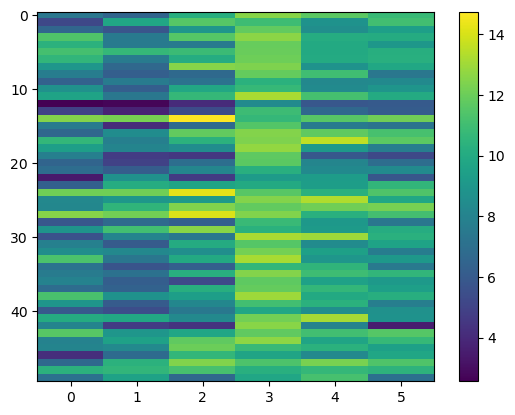

In [195]:
plt.imshow(mrsol["mrsol"].values, aspect="auto")
plt.colorbar()
plt.show()

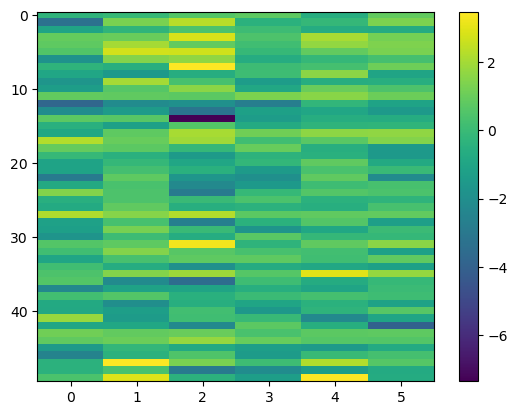

In [ ]:
plt.imshow(res["mrsol"].values, aspect="auto")
plt.colorbar()
plt.show()
